# Task 4 — Deep Learning Fundamentals
**Course:** Machine Learning & Deep Learning  
**Points:** 10/60  
**School of Artificial Intelligence and Data Science**

---

## Overview
We implement and analyze core deep learning concepts using **TensorFlow/Keras**:
- Multi-Layer Perceptron (MLP) with Dropout & Batch Normalization
- Optimizer comparison: SGD vs Adam vs RMSProp
- Conceptual questions on vanishing gradients, BN, and learning rate
- Using **Dataset A from Task 2** (Gaming vs Academic Performance)

## Step 0 — Imports & Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU available: False


## Step 1 — Data Preparation

In [13]:
def load_and_preprocess_dataset_A():
    import os
    csv_path = os.path.join('..', 'data', 'Gaming_Academic_Performance.csv')
    try:
        df = pd.read_csv(csv_path)
        print(f'Using dataset from {csv_path}')
    except FileNotFoundError:
        print('CSV not found — generating synthetic dataset with same schema...')
        np.random.seed(42)
        n = 1500
        df = pd.DataFrame({
            'student_id': [f'S{i:04d}' for i in range(n)],
            'age': np.random.randint(15, 25, n),
            'gender': np.random.choice(['Male','Female','Other'], n),
            'gaming_hours': np.random.uniform(0, 12, n),
            'study_hours': np.random.uniform(0, 10, n),
            'sleep_hours': np.random.uniform(4, 10, n),
            'attendance': np.random.uniform(50, 100, n),
            'gaming_genre': np.random.choice(['Action','RPG','Sports','Strategy','Puzzle'], n),
            'social_activity': np.random.uniform(1, 10, n),
            'device_usage': np.random.uniform(1, 12, n),
            'reaction_time_ms': np.random.uniform(150, 500, n),
            'addiction_score': np.random.uniform(1, 10, n),
            'stress_level': np.random.choice(['Low','Medium','High'], n),
        })
        df['grades'] = (40 + df['study_hours']*4 - df['gaming_hours']*1.5 +
                        df['sleep_hours']*1.5 + df['attendance']*0.2 +
                        np.random.normal(0, 8, n)).clip(0, 100)

    print(f'Shape: {df.shape}')
    print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')
    df.drop(columns=['student_id'], errors='ignore', inplace=True)
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col])
    df['performance'] = pd.cut(df['grades'], bins=[0,50,75,100], labels=['Low','Medium','High'])
    df['performance'] = LabelEncoder().fit_transform(df['performance'].astype(str))
    df.drop(columns=['grades'], inplace=True)
    print(f'\nClass distribution:\n{pd.Series(df["performance"]).value_counts()}')
    return df.drop(columns=['performance']), df['performance']

X_A, y_A = load_and_preprocess_dataset_A()

def prepare_data():
    X = X_A.astype(np.float32)
    y = y_A

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    NUM_CLASSES = len(np.unique(y))

    y_ohe = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_ohe,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        random_state=42
    )

    print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
    print(f'Features: {X_train.shape[1]}, Classes: {NUM_CLASSES}')

    return X_train, X_val, X_test, y_train, y_val, y_test
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data()

INPUT_DIM = X_train.shape[1]
N_CLASSES = y_train.shape[1]

Using dataset from ..\data\Gaming_Academic_Performance.csv
Shape: (8000, 14)

Missing values:
Series([], dtype: int64)

Class distribution:
performance
0    2931
2    2924
1    2010
3     135
Name: count, dtype: int64
Train: (5600, 12)  Val: (1200, 12)  Test: (1200, 12)
Features: 12, Classes: 4


## Step 2 — MLP Architecture

In [14]:
def build_mlp(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')
    ], name='mlp_classifier')
    return model

model = build_mlp(INPUT_DIM, N_CLASSES)
model.summary()

Model: "mlp_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,948 (42.77 KB)

 Trainable params: 10,564 (41.27 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 3 — Optimizer Comparison

In [15]:
def train_with_optimizer(optimizer, name, lr=0.001):
    model = build_mlp(INPUT_DIM, N_CLASSES)
    if name == 'SGD':
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif name == 'Adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                        validation_data=(X_val, y_val),
                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
                        verbose=0)
    return model, history

results = {}
for name, lr in [('SGD', 0.01), ('Adam', 0.001), ('RMSprop', 0.001)]:
    model, history = train_with_optimizer(None, name, lr)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = {'accuracy': test_acc, 'history': history}
    print(f'{name}: Test Accuracy = {test_acc:.4f}')

SGD: Test Accuracy = 0.8492
Adam: Test Accuracy = 0.8550
RMSprop: Test Accuracy = 0.8358


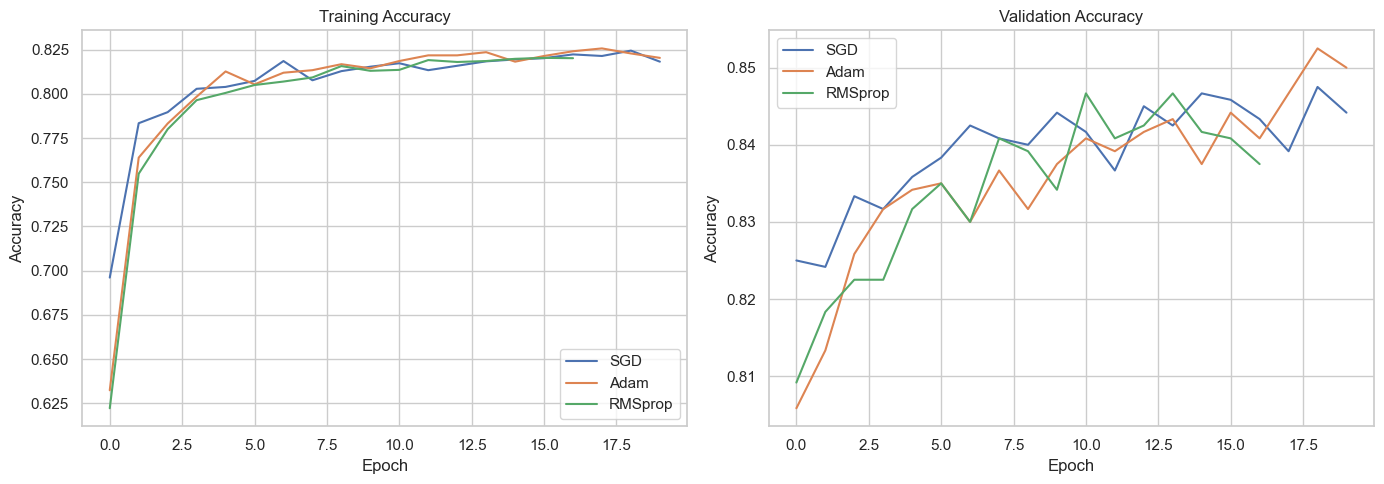

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, data in results.items():
    axes[0].plot(data['history'].history['accuracy'], label=name)
    axes[1].plot(data['history'].history['val_accuracy'], label=name)
axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('../results/T4_optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Learning Rate Study

LR=0.1: Accuracy=0.8458
LR=0.01: Accuracy=0.8408
LR=0.001: Accuracy=0.8517
LR=0.0001: Accuracy=0.8442


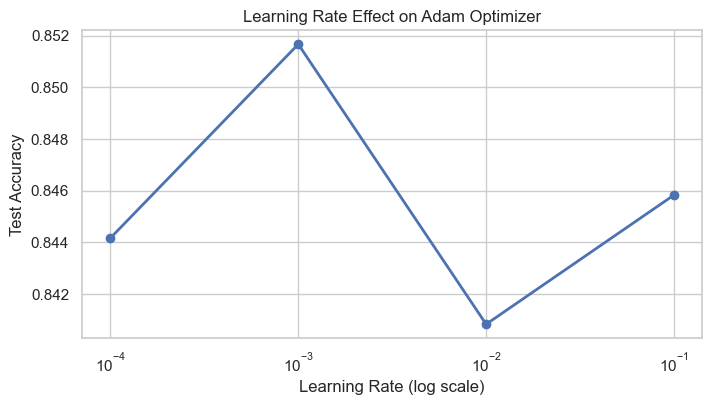

In [17]:
lrs = [0.1, 0.01, 0.001, 0.0001]
adam_accs = []
for lr in lrs:
    model, _ = train_with_optimizer(None, 'Adam', lr)
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    adam_accs.append(acc)
    print(f'LR={lr}: Accuracy={acc:.4f}')

plt.figure(figsize=(8, 4))
plt.semilogx(lrs, adam_accs, 'o-', lw=2)
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Learning Rate Effect on Adam Optimizer')
plt.grid(True)
plt.savefig('../results/T4_learning_rate_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Evaluation

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

         Low       0.82      0.92      0.87       418
      Medium       0.87      0.90      0.89       305
        High       0.85      0.78      0.82       453

   micro avg       0.85      0.86      0.85      1176
   macro avg       0.85      0.87      0.86      1176
weighted avg       0.85      0.86      0.85      1176



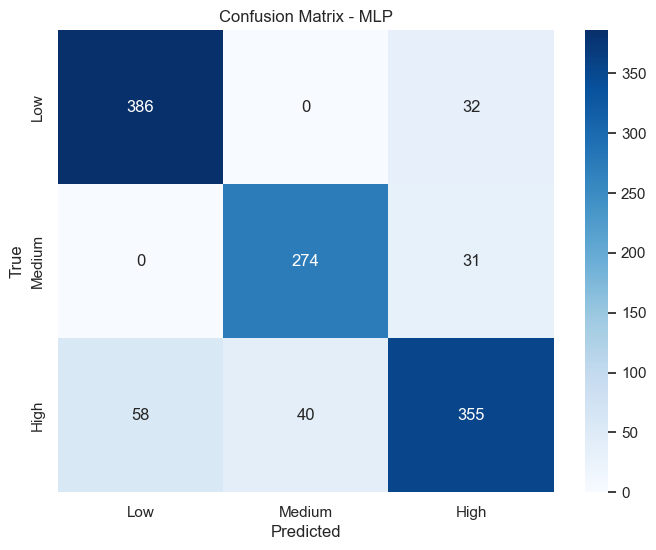

In [18]:
model, _ = train_with_optimizer('Adam', 0.001)

# Predictions
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Dynamic class names
class_names = ['Low', 'Medium', 'High']

# Classification report
print(classification_report(
    y_true,
    y_pred_classes,
    labels=[0, 1, 2],
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred_classes,
    labels=[0, 1, 2]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MLP')

plt.savefig(
    '../results/T4_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Conceptual Questions

**1. Vanishing Gradient Problem:** In deep networks, gradients become smaller as they propagate backward through layers, causing early layers to learn slowly. Solutions: ReLU activation, Batch Normalization, residual connections (ResNet).

**2. Batch Normalization:** Normalizes layer inputs during training, enabling higher learning rates, faster convergence, and reducing internal covariate shift. Works best after Dense/Conv layers before activation.

**3. Learning Rate Selection:** Too high causes divergence, too low causes slow convergence. Use learning rate schedulers (ReduceLROnPlateau) and validation curves to find optimal values.